<a href="https://colab.research.google.com/github/wonderalexandre/MTLearn/blob/cfp%2Fscoring-regularization-examples/notebooks/experiments/CFP_soft_threshold_scoring_screws_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CFP custom scoring on the screws segmentation dataset

This notebook is a compact segmentation example for the custom CFP scoring API. It uses the same `SingleAttributeSoftThresholdScorer` as the filtering notebook, but optimizes it with a segmentation loss and evaluates mask metrics.

# Colab instalation

In [1]:
%cd /content
!rm -rf MTLearn
!git clone --recursive --branch cfp/scoring-regularization-examples https://github.com/wonderalexandre/MTLearn.git

%cd /content/MTLearn
!python -m pip install ".[notebooks]"

%cd /content

import sys, importlib
for name in list(sys.modules):
    if name == "mtlearn" or name.startswith("mtlearn."):
        del sys.modules[name]
sys.path = [p for p in sys.path if not p.startswith("/content/MTLearn")]
importlib.invalidate_caches()

/content
Cloning into 'MTLearn'...
remote: Enumerating objects: 950, done.
remote: Counting objects: 100% (536/536), done.
remote: Compressing objects: 100% (310/310), done.
remote: Total 950 (delta 252), reused 446 (delta 211), pack-reused 414 (from 1)
Receiving objects: 100% (950/950), 63.50 MiB | 28.56 MiB/s, done.
Resolving deltas: 100% (433/433), done.
Submodule 'external/MorphologicalAttributeFilters' (https://github.com/wonderalexandre/MorphologicalAttributeFilters) registered for path 'external/MorphologicalAttributeFilters'
Cloning into '/content/MTLearn/external/MorphologicalAttributeFilters'...
remote: Enumerating objects: 2975, done.        
remote: Counting objects: 100% (144/144), done.        
remote: Compressing objects: 100% (105/105), done.        
remote: Total 2975 (delta 49), reused 52 (delta 38), pack-reused 2831 (from 1)        
Receiving objects: 100% (2975/2975), 36.93 MiB | 32.46 MiB/s, done.
Resolving deltas: 100% (2104/2104), done.
Submodule path 'external/M

## Setup

Resolve the local checkout, import the libraries, fix the random seed, and select the best available device.

In [2]:
#!pip install mtlearn

import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import mtlearn
from mtlearn import morphology
from mtlearn.layers import ConnectedFilterPreprocessingLayer
from mtlearn.layers.cfp import ScoringModel
import mtlearn.layers.cfp as cfp

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
generator = torch.Generator().manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

device: cuda


## Experiment configuration

The target mask is generated by a hard max-tree circularity filter. The learnable CFP layer uses the same attribute and the same custom soft-threshold scorer used in the filtering example.

In [3]:
DATASET_NAME = "screws_segmentation"
NUM_ROWS = 256
NUM_COLS = 256
BATCH_SIZE = 8
OUTPUT_SCALE = 255.0
RESPONSE_THRESHOLD = 0.5

TARGET_TREE_TYPE = "max-tree"
TARGET_TREE_ENUM = morphology.TreeType.MAX_TREE
TARGET_ATTRIBUTE = morphology.Attribute.CIRCULARITY
TARGET_ATTRIBUTE_TYPE = morphology.AttributeType.CIRCULARITY
TARGET_THRESHOLD_ORIGINAL = 0.6

FILTER_KEY = "max_circularity_soft_threshold"
INITIAL_LAMBDA = 0.0
SCORE_SHARPNESS = 20.0
CLAMP_LOGIT = 12.0
LEARNING_RATE = 0.01
NUM_EPOCHS = 100
REPORT_EPOCHS = {1, 5, 10, 20, 50, 100}

config = {
    "task": "segmentation",
    "tree": TARGET_TREE_TYPE,
    "attribute": TARGET_ATTRIBUTE.name,
    "target_threshold_original": TARGET_THRESHOLD_ORIGINAL,
    "scoring": "single_attribute_soft_threshold",
    "initial_lambda": INITIAL_LAMBDA,
    "score_sharpness": SCORE_SHARPNESS,
    "learning_rate": LEARNING_RATE,
    "num_epochs": NUM_EPOCHS,
    "response_threshold": RESPONSE_THRESHOLD,
}
display(pd.DataFrame([config]))

,task,tree,attribute,target_threshold_original,scoring,initial_lambda,score_sharpness,learning_rate,num_epochs,response_threshold
0,segmentation,max-tree,CIRCULARITY,0.6,single_attribute_soft_threshold,0.0,20.0,0.01,100,0.5


## Dataset

The dataset provides normalized input images and normalized segmentation masks. The mask is built from the original `uint8` image before dataset scaling so that the target remains tied to the morphology operation.

screws_segmentation: downloading to /content/dat/screws_segmentation
  downloaded   9% (1.0 MB / 10.5 MB)
  downloaded  19% (2.0 MB / 10.5 MB)
  downloaded  28% (3.0 MB / 10.5 MB)
  downloaded  38% (4.0 MB / 10.5 MB)
  downloaded  47% (5.0 MB / 10.5 MB)
  downloaded  57% (6.0 MB / 10.5 MB)
  downloaded  66% (7.0 MB / 10.5 MB)
  downloaded  76% (8.0 MB / 10.5 MB)
  downloaded  86% (9.0 MB / 10.5 MB)
  downloaded  95% (10.0 MB / 10.5 MB)
  downloaded 100% (10.5 MB / 10.5 MB)
  downloaded 10.5 MB
screws_segmentation: ready at /content/dat/screws_segmentation
trainset: 35
testset: 15


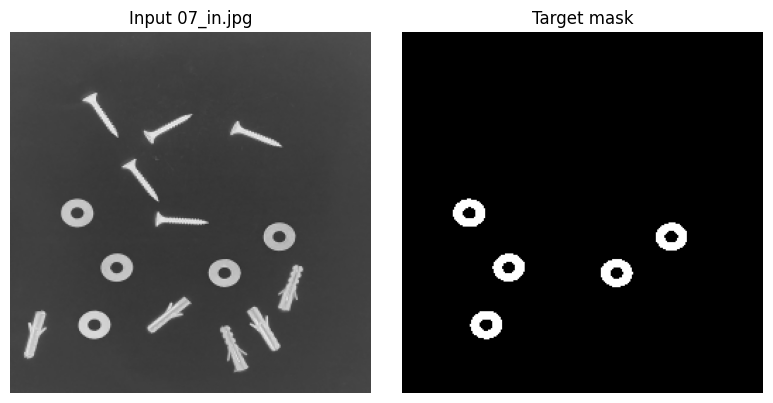

In [4]:
def segmentation_target_fn(img):
    img_u8 = np.asarray(img)
    if img_u8.ndim != 2:
        raise ValueError(f"Expected grayscale image (H, W), got shape={img_u8.shape}")
    if img_u8.dtype != np.uint8:
        img_u8 = np.clip(img_u8, 0, 255).astype(np.uint8)

    tree = morphology.build_tree(img_u8, TARGET_TREE_TYPE)
    attr_values = morphology.compute_single_attribute(tree, TARGET_ATTRIBUTE)
    filters = morphology.create_attribute_filter(tree)
    filtered = filters.filteringSubtractiveRule(attr_values > TARGET_THRESHOLD_ORIGINAL)
    return np.where(filtered > 128, 255, 0).astype(np.uint8)


dir_name = str(mtlearn.data.ensure_dataset(DATASET_NAME))
dataset = mtlearn.datasets.GeneratedTargetImageDataset(
    root_dir=dir_name,
    num_rows=NUM_ROWS,
    num_cols=NUM_COLS,
    suffix_in="_in",
    grayscale=True,
    invert_in=True,
    scale_in=True,
    scale_out=True,
    target_fn=segmentation_target_fn,
)

trainset, testset = dataset.train_test_split(test_size=0.3, random_state=SEED)
print("trainset:", len(trainset))
print("testset:", len(testset))

image_in, image_target, name = trainset[0]
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image_in.squeeze().detach().numpy(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Input {name}")
axes[1].imshow(image_target.squeeze().detach().numpy(), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Target mask")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

trainset = [(x.to(device), y.to(device), name) for x, y, name in trainset]
testset = [(x.to(device), y.to(device), name) for x, y, name in testset]
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=False,
    generator=generator,
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=False,
)

## Scoring model

This is the same custom scorer used in the filtering notebook. It keeps the scoring model simple: one attribute, one learned `lambda_`, and the filter-spec `score_sharpness` controlling sigmoid sharpness.

In [5]:
class SingleAttributeSoftThresholdScorer(ScoringModel):
    kind = "single_attribute_soft_threshold"

    def __init__(self, num_features: int, *, initial_lambda: float = 0.0):
        super().__init__()
        if int(num_features) != 1:
            raise ValueError("single_attribute_soft_threshold requires exactly one feature.")
        self.num_features = int(num_features)
        self.initial_lambda = float(initial_lambda)
        self.lambda_ = torch.nn.Parameter(torch.tensor(self.initial_lambda, dtype=torch.float32))

    def forward(self, features, tree_info=None, context=None, *, score_sharpness=None, clamp=None):
        if features.dim() != 2 or features.size(1) != self.num_features:
            raise ValueError(f"expected features with shape (num_nodes, {self.num_features}), got {tuple(features.shape)}")

        sharpness = 1.0 if score_sharpness is None else float(score_sharpness)
        lambda_value = self.lambda_.to(dtype=features.dtype, device=features.device)
        logits = sharpness * (features[:, 0] - lambda_value)
        if clamp is not None:
            logits = torch.clamp(logits, clamp[0], clamp[1])
        return torch.sigmoid(logits)

    def to_config(self):
        return {"kind": self.kind, "initial_lambda": self.initial_lambda}


def create_single_attribute_soft_threshold_scorer(*, num_features: int, initial_lambda: float = 0.0, **options):
    if options:
        names = ", ".join(sorted(options))
        raise ValueError(f"unsupported single_attribute_soft_threshold scoring options: {names}")
    return SingleAttributeSoftThresholdScorer(num_features, initial_lambda=initial_lambda)


if "single_attribute_soft_threshold" not in cfp.SCORING_MODEL_REGISTRY.registered_kinds():
    cfp.SCORING_MODEL_REGISTRY.register(
        "single_attribute_soft_threshold",
        create_single_attribute_soft_threshold_scorer,
    )

## CFP layer

The CFP layer computes max-tree circularity, normalizes the attribute with training-set `dataset_minmax01` statistics, and applies the custom soft-threshold scorer before reconstruction.

In [6]:
SCORING_CONFIG = {
    "kind": "single_attribute_soft_threshold",
    "initial_lambda": INITIAL_LAMBDA,
}

cfp_layer = ConnectedFilterPreprocessingLayer(
    in_channels=1,
    filter_specs=[
        {
            "name": FILTER_KEY,
            "tree_type": TARGET_TREE_ENUM,
            "attributes": TARGET_ATTRIBUTE_TYPE,
            "score_sharpness": SCORE_SHARPNESS,
            "scoring": SCORING_CONFIG,
        }
    ],
    scale_mode="dataset_minmax01",
    device=device,
    clamp=CLAMP_LOGIT,
)

# Caching computes tree payloads and the raw-attribute min/max statistics.
trainloader_cached = cfp_layer.build_dataloader_cached(trainloader)
testloader_cached = cfp_layer.build_dataloader_cached_fixed_stats(
    testloader,
    index_offset=len(trainset),
)

print("scoring config:", cfp_layer.get_config()["filter_specs"][0]["scoring"])
print("parameter contract:", cfp_layer.get_parameter_contract())

scoring config: {'kind': 'single_attribute_soft_threshold', 'initial_lambda': 0.0}
parameter contract: {'weights': {}, 'biases': {}, 'scoring_models': {'max_circularity_soft_threshold': {'lambda_': []}}}


## Evaluation utilities

These helpers are reused by the initial check, training reports, and final plots. The notebook reports the original-scale projection of `lambda_` and does not estimate or display a separate normalized-parameter value.

In [7]:
def normalize_per_image(batch):
    dims = tuple(range(2, batch.ndim))
    low = batch.amin(dim=dims, keepdim=True)
    high = batch.amax(dim=dims, keepdim=True)
    return (batch - low) / torch.clamp(high - low, min=1e-6)


def soft_dice_loss(probabilities, targets, eps=1e-6):
    probs = probabilities.reshape(probabilities.size(0), -1)
    masks = targets.reshape(targets.size(0), -1)
    intersection = torch.sum(probs * masks, dim=1)
    denominator = torch.sum(probs, dim=1) + torch.sum(masks, dim=1)
    return (1.0 - (2.0 * intersection + eps) / (denominator + eps)).mean()


def lambda_to_original_attribute_scale(layer, filter_key=FILTER_KEY, attr_type=TARGET_ATTRIBUTE_TYPE):
    if layer.scale_mode != "dataset_minmax01":
        raise NotImplementedError("This notebook projects lambda only for scale_mode='dataset_minmax01'.")

    scorer = layer._scoring_models[filter_key]
    spec = layer._spec_by_key[filter_key]
    stat_key = layer._stat_key(spec.tree_key, attr_type)
    stats = layer._ds_stats[stat_key]

    lambda_param = scorer.lambda_.detach()
    amin = stats["amin"].to(dtype=lambda_param.dtype, device=lambda_param.device)
    amax = stats["amax"].to(dtype=lambda_param.dtype, device=lambda_param.device)
    denom = torch.clamp(amax - amin, min=layer.eps)
    lambda_original = amin + lambda_param * denom
    return {
        "lambda_original_projection": float(lambda_original.detach().cpu()),
        "attribute_min": float(amin.detach().cpu()),
        "attribute_max": float(amax.detach().cpu()),
    }


def evaluate_segmentation(layer, dataloader):
    was_training = layer.training
    layer.eval()
    total_loss = 0.0
    total_batches = 0
    tp = fp = fn = tn = 0.0

    with torch.no_grad():
        for batch_inputs, targets in dataloader:
            response = normalize_per_image(layer(batch_inputs) / OUTPUT_SCALE)
            prediction = response >= RESPONSE_THRESHOLD
            target = targets >= 0.5

            total_loss += float(soft_dice_loss(response, targets).detach().cpu())
            total_batches += 1
            tp += torch.sum(prediction & target).item()
            fp += torch.sum(prediction & ~target).item()
            fn += torch.sum(~prediction & target).item()
            tn += torch.sum(~prediction & ~target).item()

    layer.train(was_training)
    eps = 1e-12
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    return {
        "soft_dice_loss": total_loss / max(total_batches, 1),
        "iou": tp / (tp + fp + fn + eps),
        "f1": 2.0 * precision * recall / (precision + recall + eps),
        "precision": precision,
        "recall": recall,
        "accuracy": (tp + tn) / (tp + fp + fn + tn + eps),
        "foreground_fraction": (tp + fn) / (tp + fp + fn + tn + eps),
    }

## Initial state

Before any optimizer update, `lambda_` is fixed by the explicit initial value. The table reports only the original-scale projection and segmentation metrics.

In [8]:
initial_train = evaluate_segmentation(cfp_layer, trainloader_cached)
initial_test = evaluate_segmentation(cfp_layer, testloader_cached)
initial_report = lambda_to_original_attribute_scale(cfp_layer)
initial_report.update({f"train_{key}": value for key, value in initial_train.items()})
initial_report.update({f"test_{key}": value for key, value in initial_test.items()})

print("Before training: lambda_ starts from the configured initial value.")
display(pd.DataFrame([initial_report]))

Before training: lambda_ starts from the configured initial value.


,lambda_original_projection,attribute_min,attribute_max,train_soft_dice_loss,train_iou,train_f1,train_precision,train_recall,train_accuracy,train_foreground_fraction,test_soft_dice_loss,test_iou,test_f1,test_precision,test_recall,test_accuracy,test_foreground_fraction
0,0.0,0.0,1.0,0.730268,0.431863,0.603219,0.432901,0.994483,0.969915,0.022995,0.731545,0.430494,0.601882,0.431363,0.995345,0.969786,0.022946


## Training

The learning rate and `score_sharpness` are fixed. At each report epoch, the notebook evaluates train/test segmentation metrics and shows the same held-out test batch: input, target mask, normalized CFP response, and binarized prediction.

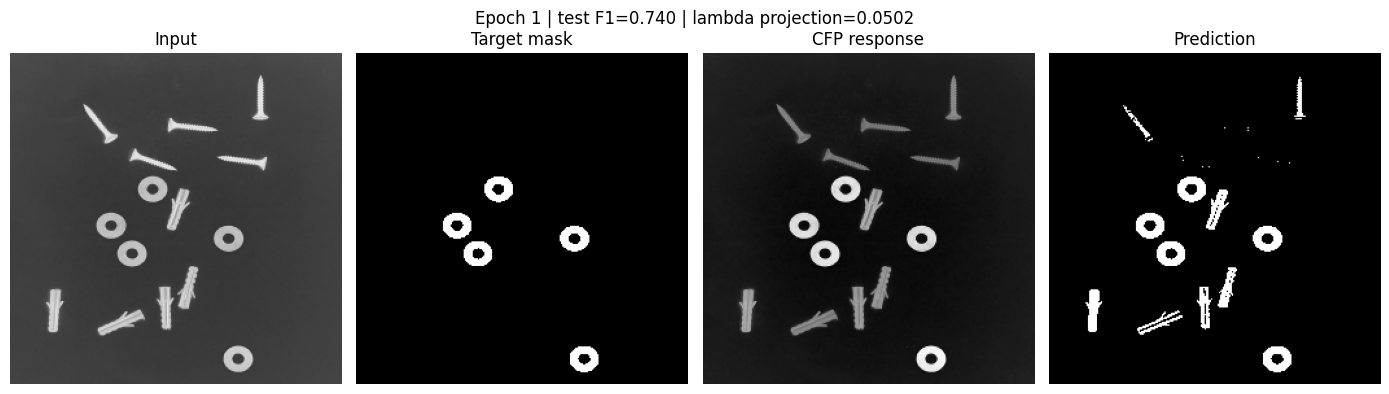

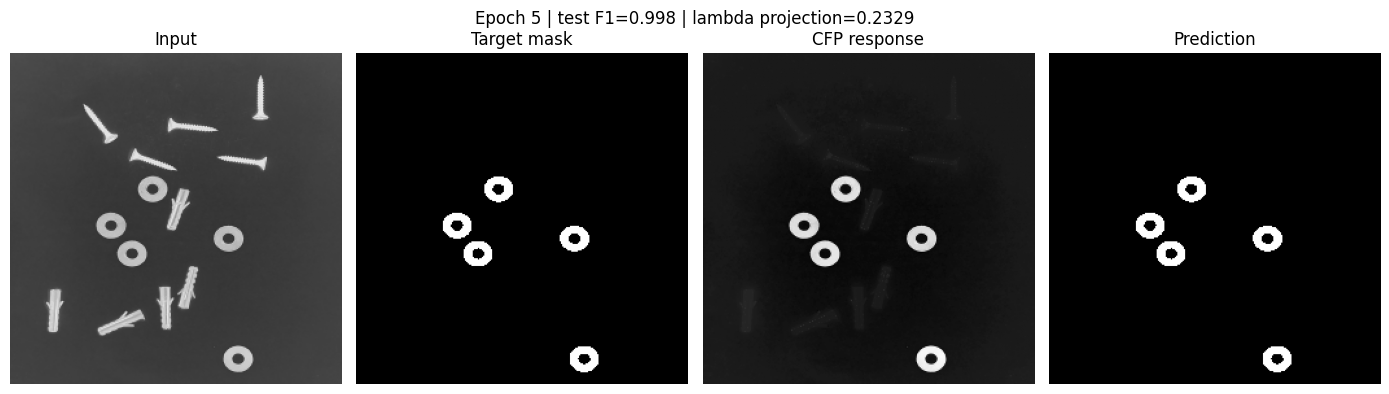

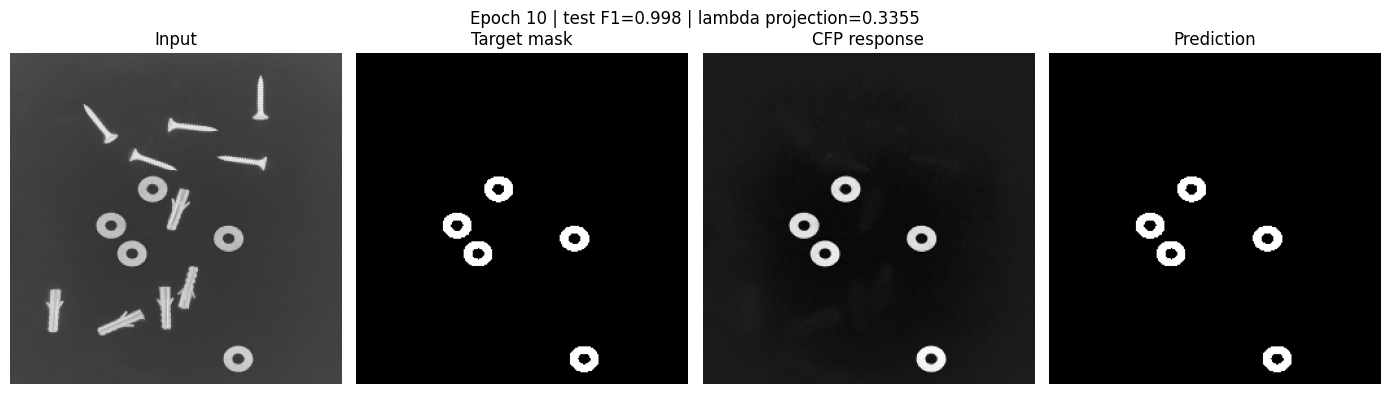

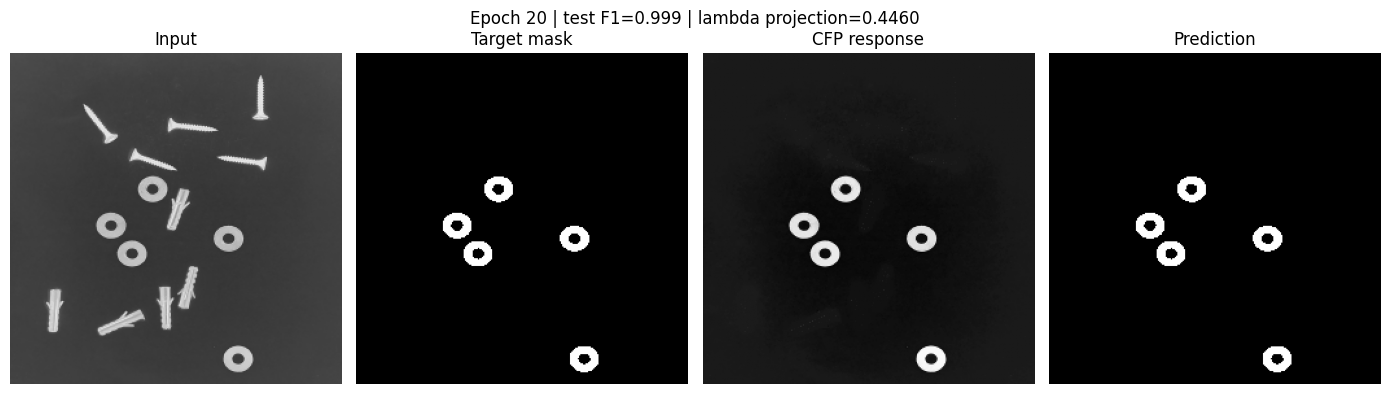

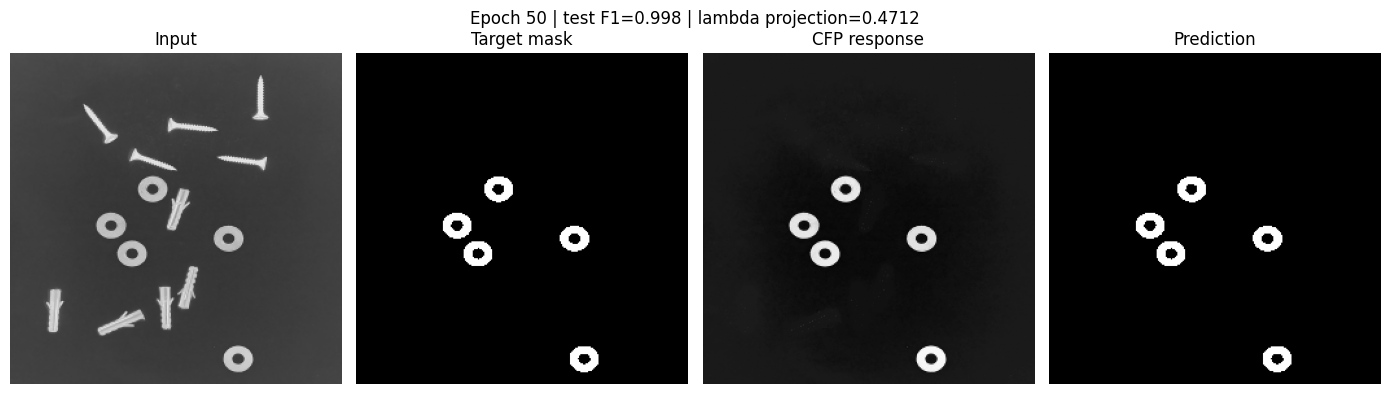

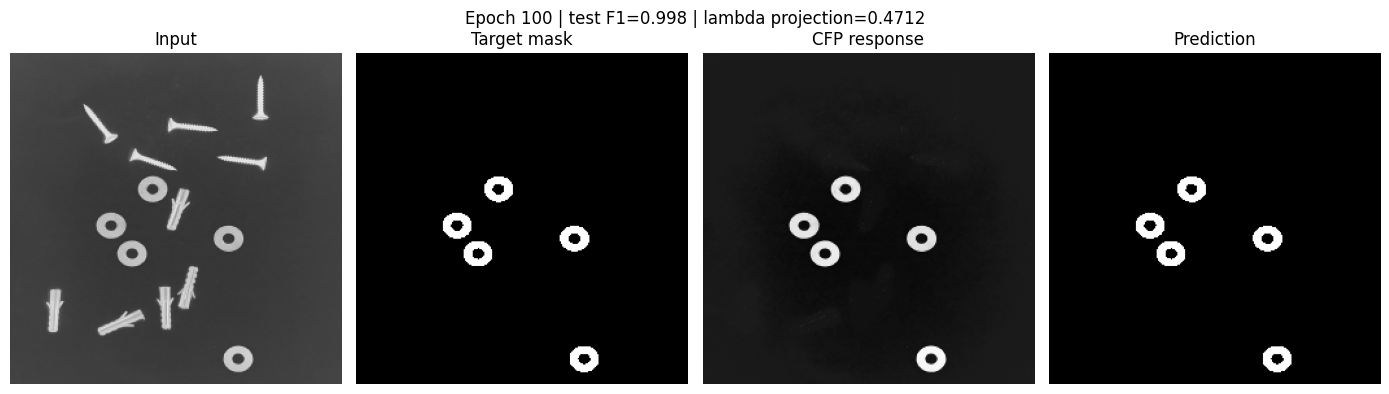

Training completed in 0.170 minutes.


In [9]:
optimizer = torch.optim.Adam(cfp_layer.parameters(), lr=LEARNING_RATE, weight_decay=0.0)
train_losses = []
report_rows = []
start = time.time()

viz_inputs, viz_targets = next(iter(testloader_cached))
viz_images = viz_inputs[0] if isinstance(viz_inputs, (tuple, list)) else viz_inputs

cfp_layer.train()
for epoch in range(1, NUM_EPOCHS + 1):
    epoch_loss = 0.0
    last_grad_lambda = None

    for batch_inputs, targets in trainloader_cached:
        response = normalize_per_image(cfp_layer(batch_inputs) / OUTPUT_SCALE)
        loss = soft_dice_loss(response, targets)

        optimizer.zero_grad()
        loss.backward()
        scorer = cfp_layer._scoring_models[FILTER_KEY]
        if scorer.lambda_.grad is not None:
            last_grad_lambda = float(scorer.lambda_.grad.detach().cpu())
        torch.nn.utils.clip_grad_norm_(cfp_layer.parameters(), max_norm=5.0)
        optimizer.step()

        epoch_loss += loss.item()

    train_epoch_loss = epoch_loss / len(trainloader_cached)
    train_losses.append(train_epoch_loss)

    if epoch in REPORT_EPOCHS:
        train_metrics = evaluate_segmentation(cfp_layer, trainloader_cached)
        test_metrics = evaluate_segmentation(cfp_layer, testloader_cached)
        row = lambda_to_original_attribute_scale(cfp_layer)
        row.update(
            {
                "epoch": epoch,
                "train_epoch_soft_dice_loss": train_epoch_loss,
                "learning_rate": LEARNING_RATE,
                "grad_lambda_last_batch": last_grad_lambda,
            }
        )
        row.update({f"train_{key}": value for key, value in train_metrics.items()})
        row.update({f"test_{key}": value for key, value in test_metrics.items()})
        report_rows.append(row)

        was_training = cfp_layer.training
        cfp_layer.eval()
        with torch.no_grad():
            viz_response = normalize_per_image(cfp_layer(viz_inputs) / OUTPUT_SCALE)
            viz_prediction = viz_response >= RESPONSE_THRESHOLD
        cfp_layer.train(was_training)

        fig, axes = plt.subplots(1, 4, figsize=(14, 4))
        axes[0].imshow(viz_images[0, 0].detach().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
        axes[0].set_title("Input")
        axes[1].imshow(viz_targets[0, 0].detach().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
        axes[1].set_title("Target mask")
        axes[2].imshow(viz_response[0, 0].detach().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
        axes[2].set_title("CFP response")
        axes[3].imshow(viz_prediction[0, 0].detach().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
        axes[3].set_title("Prediction")
        for axis in axes:
            axis.axis("off")
        fig.suptitle(
            f"Epoch {epoch} | test F1={row['test_f1']:.3f} | "
            f"lambda projection={row['lambda_original_projection']:.4f}"
        )
        plt.tight_layout()
        plt.show()

elapsed_minutes = (time.time() - start) / 60.0
trajectory = pd.DataFrame(report_rows)
print(f"Training completed in {elapsed_minutes:.3f} minutes.")

## Results

The table shows the fixed-learning-rate trajectory. The plotted horizontal line is the hard threshold used to generate the target; the learned curve is the original-scale projection of `lambda_`.

,epoch,lambda_original_projection,train_soft_dice_loss,test_soft_dice_loss,train_iou,test_iou,train_f1,test_f1,learning_rate
0,1,0.050175,0.715933,0.717344,0.596038,0.587045,0.746897,0.739796,0.01
1,5,0.232895,0.677323,0.679164,0.986799,0.996411,0.993356,0.998202,0.01
2,10,0.335451,0.672757,0.674970,0.996664,0.996987,0.998329,0.998491,0.01
3,20,0.445988,0.669753,0.672050,0.997081,0.997032,0.998538,0.998514,0.01
4,50,0.471237,0.669603,0.671855,0.997138,0.996988,0.998567,0.998492,0.01
5,100,0.471235,0.669603,0.671855,0.997138,0.996988,0.998567,0.998492,0.01


Final report
lambda_ is learned by the custom scorer; this report projects it to the original attribute scale.


,lambda_original_projection,attribute_min,attribute_max,train_soft_dice_loss,train_iou,train_f1,train_precision,train_recall,train_accuracy,train_foreground_fraction,test_soft_dice_loss,test_iou,test_f1,test_precision,test_recall,test_accuracy,test_foreground_fraction
0,0.471235,0.0,1.0,0.669603,0.997138,0.998567,0.999677,0.99746,0.999934,0.022995,0.671855,0.996988,0.998492,0.99929,0.997695,0.999931,0.022946


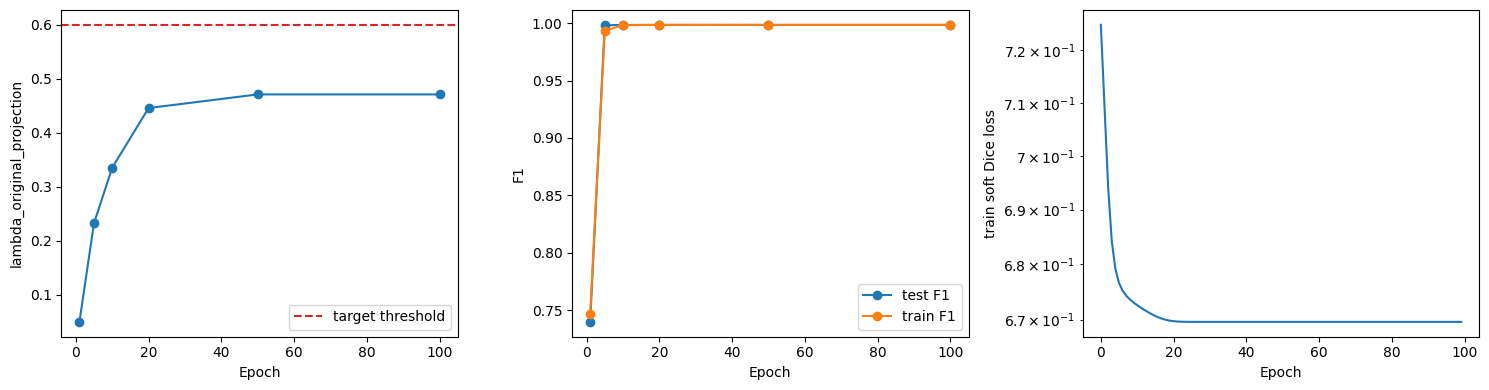

In [10]:
display_columns = [
    "epoch",
    "lambda_original_projection",
    "train_soft_dice_loss",
    "test_soft_dice_loss",
    "train_iou",
    "test_iou",
    "train_f1",
    "test_f1",
    "learning_rate",
]
display(trajectory[display_columns])

final_report = lambda_to_original_attribute_scale(cfp_layer)
final_report.update({f"train_{key}": value for key, value in evaluate_segmentation(cfp_layer, trainloader_cached).items()})
final_report.update({f"test_{key}": value for key, value in evaluate_segmentation(cfp_layer, testloader_cached).items()})

print("Final report")
print("lambda_ is learned by the custom scorer; this report projects it to the original attribute scale.")
display(pd.DataFrame([final_report]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(trajectory["epoch"], trajectory["lambda_original_projection"], marker="o")
axes[0].axhline(TARGET_THRESHOLD_ORIGINAL, color="tab:red", linestyle="--", label="target threshold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("lambda_original_projection")
axes[0].legend()

axes[1].plot(trajectory["epoch"], trajectory["test_f1"], marker="o", label="test F1")
axes[1].plot(trajectory["epoch"], trajectory["train_f1"], marker="o", label="train F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1")
axes[1].legend()

axes[2].semilogy(train_losses)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("train soft Dice loss")
plt.tight_layout()
plt.show()